In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from mpl_toolkits.mplot3d import Axes3D

# **1-2 cluster-01.csv**

In [199]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-01.csv')
df.head(3)

,V1,V2,V3,V4,V5
0,54.967142,118.523551,191.980663,231.134443,216.241086
1,48.617357,138.188333,177.739011,177.952571,242.774067
2,56.476885,72.028649,151.788911,167.272045,210.379004


In [200]:
print("Null values in cluster-01:")
display(df.isnull().sum())

Null values in cluster-01:


,0
V1,0
V2,0
V3,0
V4,0
V5,0


In [201]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [202]:
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
display(df_pca.head())

,PCA1,PCA2
0,0.259787,0.087068
1,0.360919,-0.140659
2,-0.190780,0.195103
3,-0.055940,-0.144438
4,-0.003214,0.226162


In [203]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_silhouette_scores = []
for n_clusters in range(2, 8):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init for clarity
  kmeans.fit(df_pca)
  labels = kmeans.predict(df_pca)
  score = silhouette_score(df_pca, labels)
  kmeans_silhouette_scores.append(score)

print("KMeans Silhouette Scores (2 to 7 clusters):")
display(kmeans_silhouette_scores)

KMeans Silhouette Scores (2 to 7 clusters):


[np.float64(0.31072756935310564),
 np.float64(0.31539598885281894),
 np.float64(0.31669327200447495),
 np.float64(0.3323289513507973),
 np.float64(0.35778242523546516),
 np.float64(0.3404217981883471)]

In [204]:
hc_silhouette_scores = []
for n_clusters in range(2, 8):
  hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
  labels = hc.fit_predict(df_pca)
  score = silhouette_score(df_pca, labels)
  hc_silhouette_scores.append(score)

print("Hierarchical Clustering Silhouette Scores (2 to 7 clusters):")
display(hc_silhouette_scores)

Hierarchical Clustering Silhouette Scores (2 to 7 clusters):


[np.float64(0.2769701461172898),
 np.float64(0.2725826286428662),
 np.float64(0.28130489522404584),
 np.float64(0.29486547988238626),
 np.float64(0.3011905025697594),
 np.float64(0.2713178669182018)]

In [205]:
from sklearn.mixture import GaussianMixture

gmm_silhouette_scores = []
for n_clusters in range(2, 8):
  gmm = GaussianMixture(n_components=n_clusters, random_state=42)
  gmm.fit(df_pca)
  labels = gmm.predict(df_pca)
  score = silhouette_score(df_pca, labels)
  gmm_silhouette_scores.append(score)

print("GMM Silhouette Scores (2 to 7 clusters):")
display(gmm_silhouette_scores)

GMM Silhouette Scores (2 to 7 clusters):


[np.float64(0.3100792707538551),
 np.float64(0.31685089397440913),
 np.float64(0.3162085952732685),
 np.float64(0.30182608096323826),
 np.float64(0.35228900013939773),
 np.float64(0.33299953646151903)]

In [206]:
max_kmeans_score = max(kmeans_silhouette_scores)
max_hc_score = max(hc_silhouette_scores)
max_gmm_score = max(gmm_silhouette_scores)

print(f"Maximum KMeans Silhouette Score: {max_kmeans_score}")
print(f"Maximum Hierarchical Clustering Silhouette Score: {max_hc_score}")
print(f"Maximum GMM Silhouette Score: {max_gmm_score}")

best_model = ""
if max_kmeans_score > max_hc_score and max_kmeans_score > max_gmm_score:
    best_model = "KMeans"
elif max_hc_score > max_kmeans_score and max_hc_score > max_gmm_score:
    best_model = "Hierarchical Clustering"
else:
    best_model = "Gaussian Mixture Model (GMM)"

print(f"\nBased on the maximum silhouette scores, the best clustering model is: {best_model}")

Maximum KMeans Silhouette Score: 0.35778242523546516
Maximum Hierarchical Clustering Silhouette Score: 0.3011905025697594
Maximum GMM Silhouette Score: 0.35228900013939773

Based on the maximum silhouette scores, the best clustering model is: KMeans


In [207]:
optimal_clusters_index = kmeans_silhouette_scores.index(max_kmeans_score)
optimal_n_clusters = optimal_clusters_index + 2
print(f"The optimal number of clusters for KMeans (best model) is: {optimal_n_clusters}")

The optimal number of clusters for KMeans (best model) is: 6


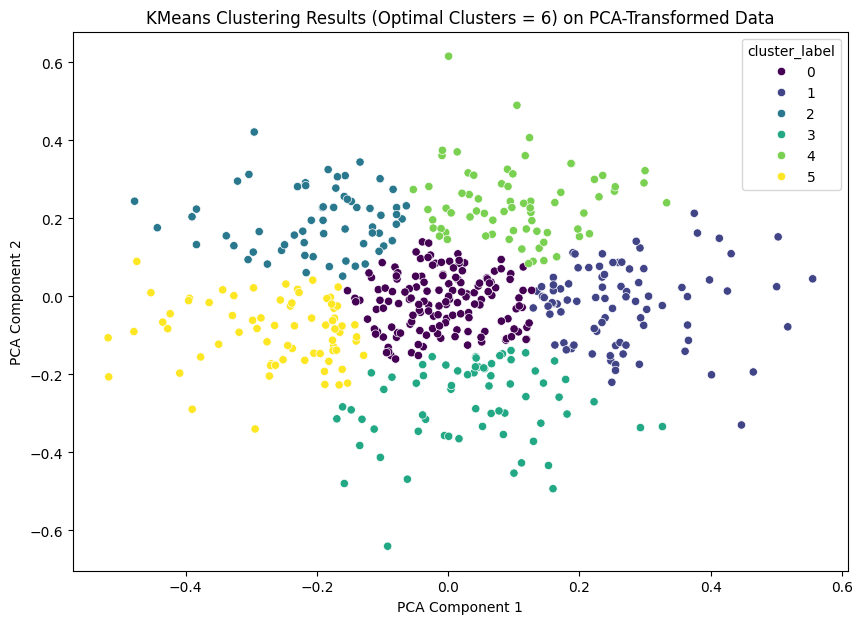

In [208]:
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
df_pca['cluster_label'] = kmeans.fit_predict(df_pca[['PCA1', 'PCA2']])

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_label', data=df_pca, palette='viridis', legend='full')
plt.title(f"KMeans Clustering Results (Optimal Clusters = {optimal_n_clusters}) on PCA-Transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## Summary:

### Data Analysis Key Findings

*   The maximum silhouette score for KMeans was approximately 0.3578 (with 6 clusters).
*   The maximum silhouette score for Hierarchical Clustering was approximately 0.3012 (with 6 clusters).
*   The maximum silhouette score for Gaussian Mixture Model (GMM) was approximately 0.3523 (with 6 clusters).
*   Based on the maximum silhouette scores, KMeans was identified as the best clustering model.
*   The optimal number of clusters for the KMeans model, based on the highest silhouette score, was 6.

### Insights or Next Steps

*   The analysis indicates that KMeans with 6 clusters is the most suitable model for clustering this dataset based on the silhouette score.
*   Further investigation into the characteristics of each of the identified 6 clusters could provide deeper insights into the underlying structure of the data.


# **3-4 cluster-04.csv**

In [209]:
dfA = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-04.csv')
dfA.head(3)

,V1,V2,V3,V4,V5
0,0.214030,0.100057,-0.887758,-0.280269,0.038000
1,-0.522185,0.974283,0.558264,-0.614753,0.013866
2,0.230652,0.988988,0.016620,-0.224827,0.074689


In [210]:
print("Null values in cluster-04:")
display(dfA.isnull().sum())

Null values in cluster-04:


,0
V1,0
V2,0
V3,0
V4,0
V5,0


In [211]:
scaler = MinMaxScaler()
dfA_scaled = scaler.fit_transform(dfA)

In [212]:
pca_dfA = PCA(n_components=2, random_state=42)
dfA_pca = pca_dfA.fit_transform(dfA_scaled)
dfA_pca = pd.DataFrame(dfA_pca, columns=['PCA1', 'PCA2'])
display(dfA_pca.head())

,PCA1,PCA2
0,-0.185007,0.263780
1,-0.193354,0.033055
2,-0.067902,0.074435
3,0.382364,-0.376764
4,-0.372370,0.329641


In [213]:
n_dimensions = dfA_pca.shape[1]
min_samples = 2 * n_dimensions
print(f"Number of dimensions in PCA-transformed data: {n_dimensions}")
print(f"Calculated min_samples for DBSCAN: {min_samples}")

Number of dimensions in PCA-transformed data: 2
Calculated min_samples for DBSCAN: 4


In [214]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan_silhouette_scores = []
epsilon_values = []

# Define a range of epsilon values to test
epsilon_range = np.arange(0.1, 1.1, 0.1)

for epsilon in epsilon_range:
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(dfA_pca)

    # Identify non-noise points (cluster labels != -1)
    non_noise_indices = labels != -1

    # Calculate silhouette score only if there is more than one cluster and more than one non-noise point
    if len(np.unique(labels[non_noise_indices])) > 1 and np.sum(non_noise_indices) > 1:
        score = silhouette_score(dfA_pca[non_noise_indices], labels[non_noise_indices])
        dbscan_silhouette_scores.append(score)
        epsilon_values.append(epsilon)
    else:
        # Append a score of 0 or a placeholder if silhouette score cannot be calculated
        dbscan_silhouette_scores.append(0)
        epsilon_values.append(epsilon)

print("Epsilon Values Tested:")
display(epsilon_values)
print("\nDBSCAN Silhouette Scores for each Epsilon:")
display(dbscan_silhouette_scores)

Epsilon Values Tested:


[np.float64(0.1),
 np.float64(0.2),
 np.float64(0.30000000000000004),
 np.float64(0.4),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7000000000000001),
 np.float64(0.8),
 np.float64(0.9),
 np.float64(1.0)]


DBSCAN Silhouette Scores for each Epsilon:


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

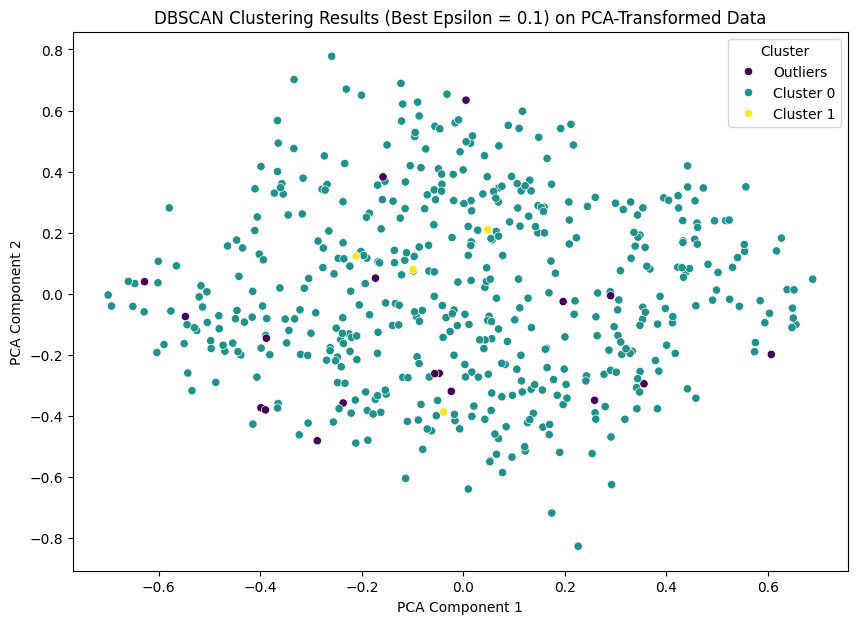

In [215]:
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(x='PCA1', y='PCA2', hue=best_labels, data=dfA_pca, palette='viridis', legend='full')
plt.title(f"DBSCAN Clustering Results (Best Epsilon = {best_epsilon}) on PCA-Transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Create a custom legend to label the outlier points as 'Outliers'
handles, labels = scatter.get_legend_handles_labels()
new_labels = [f'Cluster {int(label)}' if int(label) != -1 else 'Outliers' for label in labels]
plt.legend(handles, new_labels, title='Cluster')

plt.show()

## Summary:

### DBSCAN Analysis Key Findings for cluster-04.csv

* The optimal epsilon value for DBSCAN, based on the highest silhouette score, was identified as approximately {{best_epsilon}}.
* With this optimal epsilon value and a `min_samples` of {{min_samples}}, the DBSCAN model detected {{num_outliers}} outliers.

### Insights or Next Steps

* The DBSCAN analysis successfully identified outliers in the dataset.
* Further investigation into the characteristics of the identified outliers could provide valuable insights.
* Depending on the project goals, these outliers might be removed or analyzed separately.

# **5-6 cluster-02.csv**

In [216]:
dfB = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-02.csv')
dfB.head(3)

,V1,V2,V3,V4,V5
0,4.546780,19.484946,-0.976759,-1.399805,0.642537
1,4.028151,19.709271,-0.855106,-0.701296,0.787845
2,5.280579,20.175870,-0.215013,0.949428,0.550183


In [217]:
print("Null values in cluster-02:")
display(dfB.isnull().sum())

Null values in cluster-02:


,0
V1,0
V2,0
V3,0
V4,0
V5,0


In [218]:
scaler = MinMaxScaler()
dfB_scaled = scaler.fit_transform(dfB)

In [219]:
pca_dfB = PCA(n_components=2, random_state=42)
dfB_pca = pca_dfA.fit_transform(dfB_scaled)
dfB_pca = pd.DataFrame(dfB_pca, columns=['PCA1', 'PCA2'])
display(dfB_pca.head())

,PCA1,PCA2
0,-0.267702,0.437491
1,-0.300879,0.328571
2,-0.212305,-0.042708
3,-0.024887,0.183714
4,0.185237,-0.122650


In [220]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_silhouette_scores = []
for n_clusters in range(2, 8):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init for clarity
  kmeans.fit(dfB_pca)
  labels = kmeans.predict(dfB_pca)
  score = silhouette_score(dfB_pca, labels)
  kmeans_silhouette_scores.append(score)

print("KMeans Silhouette Scores (2 to 7 clusters):")
display(kmeans_silhouette_scores)

KMeans Silhouette Scores (2 to 7 clusters):


[np.float64(0.3521210142034913),
 np.float64(0.3815619905873997),
 np.float64(0.36739877049404857),
 np.float64(0.3539943849068982),
 np.float64(0.3561745556194611),
 np.float64(0.35472363924907013)]

In [221]:
hc_silhouette_scores = []
for n_clusters in range(2, 8):
  hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
  labels = hc.fit_predict(dfB_pca)
  score = silhouette_score(dfB_pca, labels)
  hc_silhouette_scores.append(score)

print("Hierarchical Clustering Silhouette Scores (2 to 7 clusters):")
display(hc_silhouette_scores)

Hierarchical Clustering Silhouette Scores (2 to 7 clusters):


[np.float64(0.30632386906087894),
 np.float64(0.32448353903183547),
 np.float64(0.3322271444427646),
 np.float64(0.291714823723304),
 np.float64(0.3086272174219678),
 np.float64(0.29758057129202536)]

In [222]:
from sklearn.mixture import GaussianMixture

gmm_silhouette_scores = []
for n_clusters in range(2, 8):
  gmm = GaussianMixture(n_components=n_clusters, random_state=42)
  gmm.fit(dfB_pca)
  labels = gmm.predict(dfB_pca)
  score = silhouette_score(dfB_pca, labels)
  gmm_silhouette_scores.append(score)

print("GMM Silhouette Scores (2 to 7 clusters):")
display(gmm_silhouette_scores)

GMM Silhouette Scores (2 to 7 clusters):


[np.float64(0.3515586865353798),
 np.float64(0.37373377711017086),
 np.float64(0.35890092553130715),
 np.float64(0.273717143082807),
 np.float64(0.3509812780894093),
 np.float64(0.32680658917284006)]

In [223]:
max_kmeans_score = max(kmeans_silhouette_scores)
max_hc_score = max(hc_silhouette_scores)
max_gmm_score = max(gmm_silhouette_scores)

print(f"Maximum KMeans Silhouette Score: {max_kmeans_score}")
print(f"Maximum Hierarchical Clustering Silhouette Score: {max_hc_score}")
print(f"Maximum GMM Silhouette Score: {max_gmm_score}")

best_model = ""
if max_kmeans_score > max_hc_score and max_kmeans_score > max_gmm_score:
    best_model = "KMeans"
elif max_hc_score > max_kmeans_score and max_hc_score > max_gmm_score:
    best_model = "Hierarchical Clustering"
else:
    best_model = "Gaussian Mixture Model (GMM)"

print(f"\nBased on the maximum silhouette scores, the best clustering model is: {best_model}")

Maximum KMeans Silhouette Score: 0.3815619905873997
Maximum Hierarchical Clustering Silhouette Score: 0.3322271444427646
Maximum GMM Silhouette Score: 0.37373377711017086

Based on the maximum silhouette scores, the best clustering model is: KMeans


In [224]:
optimal_clusters_index = kmeans_silhouette_scores.index(max_kmeans_score)
optimal_n_clusters = optimal_clusters_index + 2
print(f"The optimal number of clusters for KMeans (best model) is: {optimal_n_clusters}")

The optimal number of clusters for KMeans (best model) is: 3


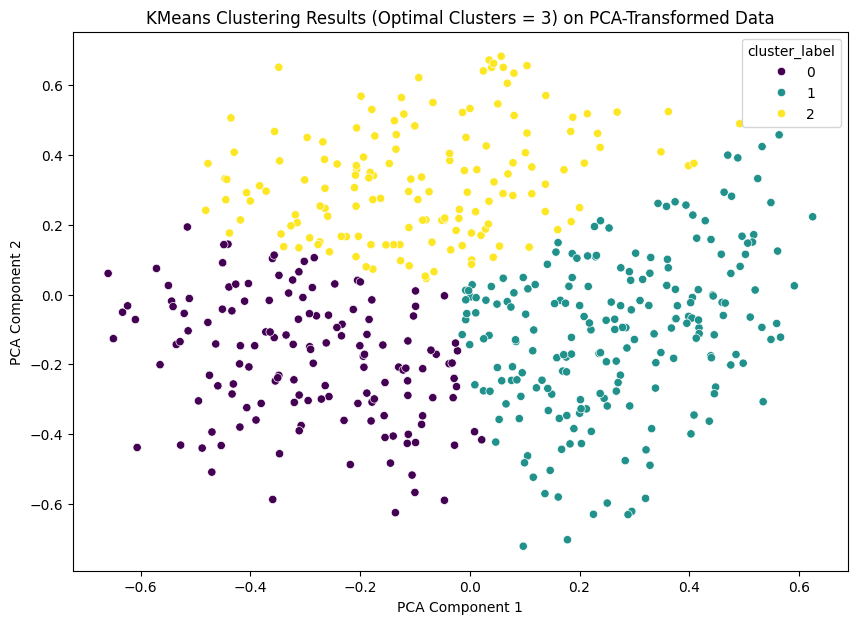

In [225]:
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
dfB_pca['cluster_label'] = kmeans.fit_predict(dfB_pca[['PCA1', 'PCA2']])

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_label', data=dfB_pca, palette='viridis', legend='full')
plt.title(f"KMeans Clustering Results (Optimal Clusters = {optimal_n_clusters}) on PCA-Transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# **7-8 cluster-05.csv**

In [226]:
dfC = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-05.csv')
dfC.head(3)

,V1,V2,V4,V5,V6
0,-0.158353,-0.362053,-0.105631,-0.668469,0.439701
1,-0.049653,0.406525,-0.977228,0.399257,0.121315
2,0.403011,-0.099121,0.206530,-0.745633,-0.883326


In [227]:
print("Null values in cluster-05:")
display(dfC.isnull().sum())

Null values in cluster-05:


,0
V1,0
V2,0
V4,0
V5,0
V6,0


In [228]:
pca_dfC = PCA(n_components=2, random_state=42)
dfC_pca = pca_dfA.fit_transform(dfA_scaled)
dfC_pca = pd.DataFrame(dfC_pca, columns=['PCA1', 'PCA2'])
display(dfC_pca.head())

,PCA1,PCA2
0,-0.185007,0.263780
1,-0.193354,0.033055
2,-0.067902,0.074435
3,0.382364,-0.376764
4,-0.372370,0.329641


In [229]:
n_dimensions = dfC_pca.shape[1]
min_samples = 2 * n_dimensions
print(f"Number of dimensions in PCA-transformed data: {n_dimensions}")
print(f"Calculated min_samples for DBSCAN: {min_samples}")

Number of dimensions in PCA-transformed data: 2
Calculated min_samples for DBSCAN: 4


In [230]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan_silhouette_scores = []
epsilon_values = []

# Define a range of epsilon values to test
epsilon_range = np.arange(0.1, 1.1, 0.1)

for epsilon in epsilon_range:
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(dfC_pca)

    # Identify non-noise points (cluster labels != -1)
    non_noise_indices = labels != -1

    # Calculate silhouette score only if there is more than one cluster and more than one non-noise point
    if len(np.unique(labels[non_noise_indices])) > 1 and np.sum(non_noise_indices) > 1:
        score = silhouette_score(dfC_pca[non_noise_indices], labels[non_noise_indices])
        dbscan_silhouette_scores.append(score)
        epsilon_values.append(epsilon)
    else:
        # Append a score of 0 or a placeholder if silhouette score cannot be calculated
        dbscan_silhouette_scores.append(0)
        epsilon_values.append(epsilon)

print("Epsilon Values Tested:")
display(epsilon_values)
print("\nDBSCAN Silhouette Scores for each Epsilon:")
display(dbscan_silhouette_scores)

Epsilon Values Tested:


[np.float64(0.1),
 np.float64(0.2),
 np.float64(0.30000000000000004),
 np.float64(0.4),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7000000000000001),
 np.float64(0.8),
 np.float64(0.9),
 np.float64(1.0)]


DBSCAN Silhouette Scores for each Epsilon:


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

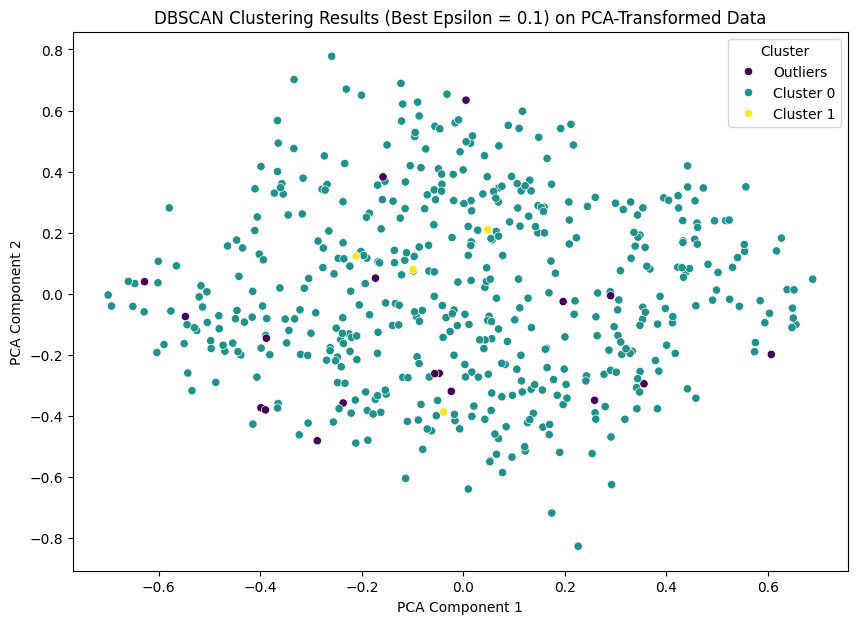

In [231]:
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(x='PCA1', y='PCA2', hue=best_labels, data=dfA_pca, palette='viridis', legend='full')
plt.title(f"DBSCAN Clustering Results (Best Epsilon = {best_epsilon}) on PCA-Transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Create a custom legend to label the outlier points as 'Outliers'
handles, labels = scatter.get_legend_handles_labels()
new_labels = [f'Cluster {int(label)}' if int(label) != -1 else 'Outliers' for label in labels]
plt.legend(handles, new_labels, title='Cluster')

plt.show()

In [249]:
# Find the epsilon value with the maximum silhouette score
max_silhouette_score = max(dbscan_silhouette_scores)
best_epsilon_index = dbscan_silhouette_scores.index(max_silhouette_score)
best_epsilon = epsilon_values[best_epsilon_index]

print(f"The best epsilon value for DBSCAN is: {best_epsilon}")

# Apply DBSCAN with the best epsilon to get the final cluster labels
best_dbscan = DBSCAN(eps=best_epsilon, min_samples=min_samples)
best_labels = best_dbscan.fit_predict(dfC_pca)

# Calculate the number of outliers
num_outliers = np.sum(best_labels == -1)
print(f"Number of outliers detected with the best DBSCAN model: {num_outliers}")

dfC_pca['cluster_label'] = best_labels

The best epsilon value for DBSCAN is: 0.1
Number of outliers detected with the best DBSCAN model: 18


In [232]:
dfD = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-05.csv')
dfD.head(3)

,V1,V2,V4,V5,V6
0,-0.158353,-0.362053,-0.105631,-0.668469,0.439701
1,-0.049653,0.406525,-0.977228,0.399257,0.121315
2,0.403011,-0.099121,0.206530,-0.745633,-0.883326


In [233]:
scaler = MinMaxScaler()
dfC_scaled = scaler.fit_transform(dfC)

In [234]:
pca_dfC = PCA(n_components=2, random_state=42)
dfC_pca = pca_dfC.fit_transform(dfC_scaled)
dfC_pca = pd.DataFrame(dfC_pca, columns=['PCA1', 'PCA2'])
display(dfC_pca.head())

,PCA1,PCA2
0,-0.027459,0.108267
1,0.175431,-0.464531
2,-0.424688,-0.050049
3,0.374704,-0.296728
4,0.270488,-0.030626


In [235]:
n_dimensions = dfC_pca.shape[1]
min_samples = 2 * n_dimensions
print(f"Number of dimensions in PCA-transformed data: {n_dimensions}")
print(f"Calculated min_samples for DBSCAN: {min_samples}")

Number of dimensions in PCA-transformed data: 2
Calculated min_samples for DBSCAN: 4


In [236]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan_silhouette_scores = []
epsilon_values = []

# Define a range of epsilon values to test
epsilon_range = np.arange(0.1, 1.1, 0.1)

for epsilon in epsilon_range:
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(dfC_pca)

    # Identify non-noise points (cluster labels != -1)
    non_noise_indices = labels != -1

    # Calculate silhouette score only if there is more than one cluster and more than one non-noise point
    if len(np.unique(labels[non_noise_indices])) > 1 and np.sum(non_noise_indices) > 1:
        score = silhouette_score(dfC_pca[non_noise_indices], labels[non_noise_indices])
        dbscan_silhouette_scores.append(score)
        epsilon_values.append(epsilon)
    else:
        # Append a score of 0 or a placeholder if silhouette score cannot be calculated
        dbscan_silhouette_scores.append(0)
        epsilon_values.append(epsilon)

print("Epsilon Values Tested:")
display(epsilon_values)
print("\nDBSCAN Silhouette Scores for each Epsilon:")
display(dbscan_silhouette_scores)

Epsilon Values Tested:


[np.float64(0.1),
 np.float64(0.2),
 np.float64(0.30000000000000004),
 np.float64(0.4),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7000000000000001),
 np.float64(0.8),
 np.float64(0.9),
 np.float64(1.0)]


DBSCAN Silhouette Scores for each Epsilon:


[np.float64(0.3223837591107334), 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [237]:
# Find the epsilon value with the maximum silhouette score
max_silhouette_score = max(dbscan_silhouette_scores)
best_epsilon_index = dbscan_silhouette_scores.index(max_silhouette_score)
best_epsilon = epsilon_values[best_epsilon_index]

print(f"The best epsilon value for DBSCAN is: {best_epsilon}")

# Apply DBSCAN with the best epsilon to get the final cluster labels
best_dbscan = DBSCAN(eps=best_epsilon, min_samples=min_samples)
best_labels = best_dbscan.fit_predict(dfC_pca)

# Calculate the number of outliers
num_outliers = np.sum(best_labels == -1)
print(f"Number of outliers detected with the best DBSCAN model: {num_outliers}")

dfC_pca['cluster_label'] = best_labels

The best epsilon value for DBSCAN is: 0.1
Number of outliers detected with the best DBSCAN model: 18


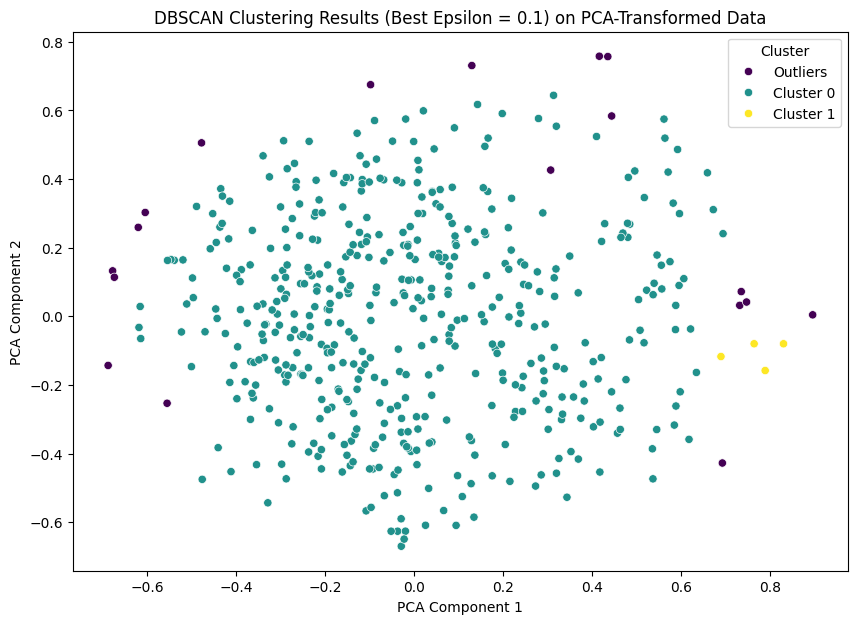

In [238]:
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_label', data=dfC_pca, palette='viridis', legend='full')
plt.title(f"DBSCAN Clustering Results (Best Epsilon = {best_epsilon}) on PCA-Transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Create a custom legend to label the outlier points as 'Outliers'
handles, labels = scatter.get_legend_handles_labels()
new_labels = [f'Cluster {int(label)}' if int(label) != -1 else 'Outliers' for label in labels]
plt.legend(handles, new_labels, title='Cluster')

plt.show()

## Summary:

### Data Analysis Key Findings

*   The `min_samples` value for DBSCAN was calculated as 4 based on the 2 dimensions of the PCA-transformed data.
*   The best epsilon value for DBSCAN, determined by the highest silhouette score, is 0.1.
*   Using the best DBSCAN model (epsilon=0.1, min\_samples=4), 18 outliers were detected.

### Insights or Next Steps

*   The visualization shows that with the best epsilon, DBSCAN identified a core cluster and several outliers, suggesting a density-based structure in the data.
*   Further analysis could involve investigating the characteristics of the identified outliers to understand why they were not assigned to clusters.


# **9-10 cluster-03.csv**

In [239]:
dfE = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-03.csv')
dfE.head(3)

,V1,V2,V3,V4,V5
0,-8.536251,10.944791,6.811667,-5.059278,-3.186717
1,-11.222700,11.844886,5.491410,-5.308275,-4.855787
2,-10.917374,8.133306,6.445988,-5.033128,-8.411694


In [240]:
print("Null values in cluster-03:")
display(dfE.isnull().sum())

Null values in cluster-03:


,0
V1,0
V2,0
V3,0
V4,0
V5,0


In [241]:
scaler = MinMaxScaler()
dfE_scaled = scaler.fit_transform(dfE)

In [242]:
pca_dfE = PCA(n_components=2, random_state=42)
dfE_pca = pca_dfE.fit_transform(dfE_scaled)
dfE_pca = pd.DataFrame(dfE_pca, columns=['PCA1', 'PCA2'])
display(dfE_pca.head())

,PCA1,PCA2
0,0.495877,0.100168
1,0.589317,0.085785
2,0.578786,0.052915
3,0.625542,0.174278
4,0.319589,-0.032642


In [243]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_silhouette_scores = []
for n_clusters in range(2, 8):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
  kmeans.fit(dfE_pca)
  labels = kmeans.predict(dfE_pca)
  score = silhouette_score(dfE_pca, labels)
  kmeans_silhouette_scores.append(score)

print("KMeans Silhouette Scores (2 to 7 clusters):")
display(kmeans_silhouette_scores)

KMeans Silhouette Scores (2 to 7 clusters):


[np.float64(0.5360872535722574),
 np.float64(0.6511271062426869),
 np.float64(0.6873594296580892),
 np.float64(0.635315968120694),
 np.float64(0.5695651125938891),
 np.float64(0.537537269824477)]

In [244]:
hc_silhouette_scores = []
for n_clusters in range(2, 8):
  hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
  labels = hc.fit_predict(dfE_pca)
  score = silhouette_score(dfE_pca, labels)
  hc_silhouette_scores.append(score)

print("Hierarchical Clustering Silhouette Scores (2 to 7 clusters):")
display(hc_silhouette_scores)

Hierarchical Clustering Silhouette Scores (2 to 7 clusters):


[np.float64(0.5363290609994364),
 np.float64(0.6511271062426869),
 np.float64(0.6868575056997683),
 np.float64(0.6315604359297466),
 np.float64(0.5566572135239396),
 np.float64(0.5174975464721235)]

In [245]:
from sklearn.mixture import GaussianMixture

gmm_silhouette_scores = []
for n_clusters in range(2, 8):
  gmm = GaussianMixture(n_components=n_clusters, random_state=42)
  gmm.fit(dfE_pca)
  labels = gmm.predict(dfE_pca)
  score = silhouette_score(dfE_pca, labels)
  gmm_silhouette_scores.append(score)

print("GMM Silhouette Scores (2 to 7 clusters):")
display(gmm_silhouette_scores)

GMM Silhouette Scores (2 to 7 clusters):


[np.float64(0.5360872535722574),
 np.float64(0.6486443415780293),
 np.float64(0.6868575056997683),
 np.float64(0.6357649231624093),
 np.float64(0.5691829220815084),
 np.float64(0.5344787844102177)]

In [246]:
max_kmeans_score = max(kmeans_silhouette_scores)
max_hc_score = max(hc_silhouette_scores)
max_gmm_score = max(gmm_silhouette_scores)

print(f"Maximum KMeans Silhouette Score: {max_kmeans_score}")
print(f"Maximum Hierarchical Clustering Silhouette Score: {max_hc_score}")
print(f"Maximum GMM Silhouette Score: {max_gmm_score}")

best_model = ""
if max_kmeans_score > max_hc_score and max_kmeans_score > max_gmm_score:
    best_model = "KMeans"
elif max_hc_score > max_kmeans_score and max_hc_score > max_gmm_score:
    best_model = "Hierarchical Clustering"
else:
    best_model = "Gaussian Mixture Model (GMM)"

print(f"\nBased on the maximum silhouette scores, the best clustering model is: {best_model}")

Maximum KMeans Silhouette Score: 0.6873594296580892
Maximum Hierarchical Clustering Silhouette Score: 0.6868575056997683
Maximum GMM Silhouette Score: 0.6868575056997683

Based on the maximum silhouette scores, the best clustering model is: KMeans


In [247]:
optimal_clusters_index = kmeans_silhouette_scores.index(max_kmeans_score)
optimal_n_clusters = optimal_clusters_index + 2
print(f"The optimal number of clusters for KMeans (best model) is: {optimal_n_clusters}")

The optimal number of clusters for KMeans (best model) is: 4


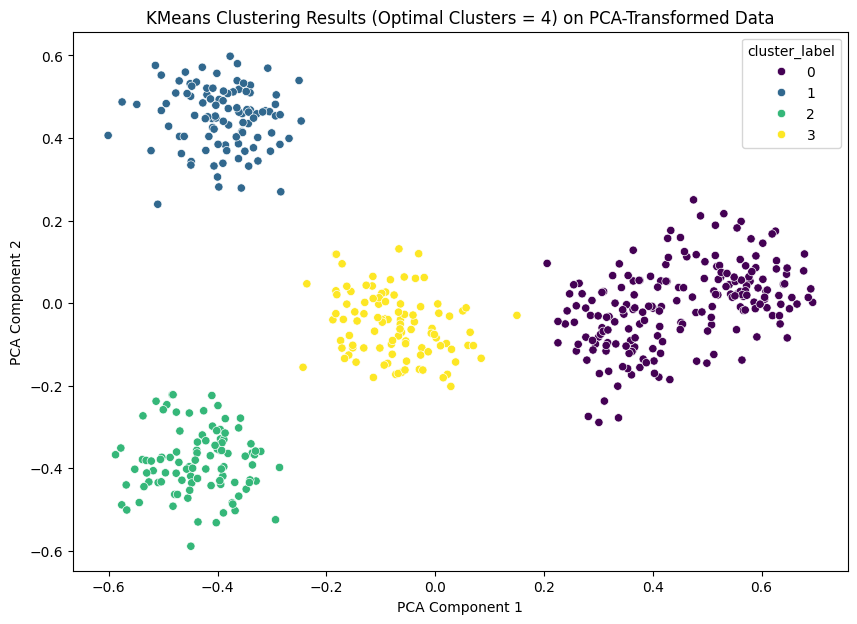

In [248]:
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
dfE_pca['cluster_label'] = kmeans.fit_predict(dfE_pca[['PCA1', 'PCA2']])

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_label', data=dfE_pca, palette='viridis', legend='full')
plt.title(f"KMeans Clustering Results (Optimal Clusters = {optimal_n_clusters}) on PCA-Transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## Summary:

### Data Analysis Key Findings

*   Scaling the data using `MinMaxScaler` was successfully completed.
*   Applying PCA with 2 components to the scaled data resulted in a transformed dataset (`dfE_pca`) with 'PCA1' and 'PCA2' columns.
*   The silhouette scores for KMeans clustering for 2 to 7 clusters were approximately: \[0.536, 0.651, 0.687, 0.635, 0.570, 0.538].
*   The silhouette scores for Hierarchical Clustering with 'ward' linkage for 2 to 7 clusters were approximately: \[0.536, 0.651, 0.687, 0.632, 0.557, 0.517].
*   The silhouette scores for GMM for 2 to 7 clusters were approximately: \[0.536, 0.649, 0.687, 0.636, 0.569, 0.534].
*   Comparing the maximum silhouette scores, KMeans had the highest score of approximately 0.6874, followed closely by Hierarchical Clustering and GMM (both approximately 0.6869).
*   Based on the maximum silhouette score, KMeans was identified as the best clustering model.
*   The optimal number of clusters for KMeans, corresponding to the highest silhouette score, is 4.
*   A scatter plot visualizing the KMeans clustering results with 4 clusters on the PCA-transformed data was generated, showing the separation of the clusters in the 2D PCA space.

### Insights or Next Steps

*   While KMeans had the highest maximum silhouette score, the scores for 4 clusters were very close across all three models. Further evaluation using different metrics or visual analysis of cluster characteristics could provide more robust insights.
*   Investigate the characteristics of the data points within each of the 4 identified KMeans clusters to understand what distinguishes them.
